# 02 — Epitope Prediction & Benchmark Validation

**ITP Tolerogenic Epitope Design Toolkit — Phase 2**

We have a working MHC-II binding prediction pipeline. This notebook
answers the critical validation question: **do our computational
predictions recover experimentally known ITP epitopes?**

We scan the full ITGB3 (GPIIIa) sequence — the primary autoantibody
target in ITP — predict MHC-II binding across 12 HLA alleles, and
measure what fraction of the 88 known ITP T-cell epitopes from IEDB
appear in the top-ranked predictions.

---
## Section 1 — Setup

Load the ITGB3 protein sequence from UniProt and the ITP-specific T-cell
epitopes from IEDB. These known epitopes are our ground truth — the
experimentally validated peptides that drive autoimmune responses in ITP
patients. The prediction engine's job is to rank these higher than random.

In [1]:
import os
import sys
import time
from pathlib import Path

def _find_project_root() -> Path:
    p = Path.cwd().resolve()
    for candidate in [p] + list(p.parents):
        if (candidate / "src").is_dir():
            return candidate
    return p

_root = _find_project_root()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
os.chdir(_root)

import matplotlib.pyplot as plt
import pandas as pd

from src.data.uniprot import fetch_sequence
from src.data.iedb import fetch_tcell_epitopes
from src.prediction.scanner import scan_sequence, filter_peptides, benchmark_recovery
from src.prediction.mhcii import predict_all_alleles, predict_binding, top_binders, HLA_PANEL

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [2]:
# Load ITGB3 sequence
entry = fetch_sequence("P05106")
itgb3_seq = entry["sequence"]
print(f"ITGB3 sequence: {entry['name']} — {len(itgb3_seq)} amino acids")

# Load ITP-specific T-cell epitopes
# Note: the IEDB disease annotation is "autoimmune thrombocytopenic purpura",
# so we filter on "thrombocytopenic purpura" (not just "thrombocytopenia",
# which matches a different, much smaller set of records).
itp_tcell = fetch_tcell_epitopes("P05106", disease_filter="thrombocytopenic purpura")
print(f"ITP T-cell epitope records: {len(itp_tcell)}")

# Extract unique epitope sequences (some records share the same peptide
# across different assays or publications)
known_epitopes = sorted(
    {r["epitope_sequence"] for r in itp_tcell if r["epitope_sequence"] is not None}
)
print(f"Unique known epitope sequences: {len(known_epitopes)}")
print(f"Length range: {min(len(e) for e in known_epitopes)}–{max(len(e) for e in known_epitopes)} aa")

ITGB3 sequence: Integrin beta-3 — 788 amino acids
ITP T-cell epitope records: 88
Unique known epitope sequences: 86
Length range: 14–15 aa


---
## Section 2 — Peptide Scanning

We slide a 15-residue window across the full ITGB3 sequence. 15-mers are
the standard input length for NetMHCIIpan — the MHC-II binding groove
accommodates a 9-mer core with flanking residues extending beyond it.
Every possible 15-mer from this 788-residue protein becomes a candidate
for MHC-II binding prediction.

In [3]:
all_scanned = scan_sequence(itgb3_seq)
peptides_15 = filter_peptides(all_scanned, min_len=15, max_len=15)

print(f"Total 15-mers from ITGB3: {len(peptides_15)}")
print(f"  (expected: {len(itgb3_seq)} - 14 = {len(itgb3_seq) - 14})")

# Preview
pd.DataFrame(peptides_15[:5])

Total 15-mers from ITGB3: 774
  (expected: 788 - 14 = 774)


,peptide,start,end,length
0,MRARPRPRPLWATVL,0,15,15
1,RARPRPRPLWATVLA,1,16,15
2,ARPRPRPLWATVLAL,2,17,15
3,RPRPRPLWATVLALG,3,18,15
4,PRPRPLWATVLALGA,4,19,15


---
## Section 3 — Full Panel Prediction

We now send all 774 15-mers to the IEDB prediction API for scoring against
each of the 12 alleles in our HLA panel. This uses `netmhciipan_el`
(eluted ligand predictor) — the state of the art for MHC-II binding
prediction.

Each allele requires multiple batched API calls (100 peptides per batch),
so the first run takes several minutes. Results are cached to
`data/processed/` — subsequent runs are instant.

**HLA panel:**
- 9 HLA-DRB1 alleles (the most polymorphic MHC-II locus)
- 2 HLA-DQ alleles (alpha/beta heterodimers)
- 1 HLA-DP allele

In [4]:
%%time

peptide_list = [p["peptide"] for p in peptides_15]

print(f"Predicting binding for {len(peptide_list)} peptides x {len(HLA_PANEL)} alleles ...")
print(f"Alleles: {', '.join(HLA_PANEL)}")
print()

full_results = predict_all_alleles(peptide_list)

print(f"\nDone. {len(full_results)} total predictions.")
print(f"  Unique alleles:   {full_results['allele'].nunique()}")
print(f"  Unique peptides:  {full_results['peptide'].nunique()}")

Predicting binding for 774 peptides x 12 alleles ...
Alleles: HLA-DRB1*01:01, HLA-DRB1*03:01, HLA-DRB1*04:01, HLA-DRB1*04:05, HLA-DRB1*07:01, HLA-DRB1*09:01, HLA-DRB1*11:01, HLA-DRB1*13:01, HLA-DRB1*15:01, HLA-DQA1*01:01/DQB1*05:01, HLA-DQA1*01:02/DQB1*06:02, HLA-DPA1*01:03/DPB1*04:01


Done. 9288 total predictions.
  Unique alleles:   12
  Unique peptides:  774
CPU times: user 40.7 ms, sys: 81 μs, total: 40.7 ms
Wall time: 11 s


---
## Section 4 — Top Binders

A percentile rank ≤ 10% is the conventional threshold for a "binder" in
MHC-II prediction — the peptide is predicted to bind at least as well as
the top 10% of random natural peptides. Within that:
- ≤ 2%: strong binder
- 2–10%: weak binder

We filter to binders and examine how they distribute across alleles.
A good tolerogenic vaccine candidate should bind multiple alleles
(population coverage).

In [5]:
binders = top_binders(full_results, percentile_threshold=10.0)

unique_binder_peptides = binders["peptide"].nunique()
strong = top_binders(full_results, percentile_threshold=2.0)
unique_strong = strong["peptide"].nunique()

print(f"Binder predictions (percentile <= 10%): {len(binders)} rows")
print(f"  Unique binder peptides: {unique_binder_peptides} / {full_results['peptide'].nunique()}")
print(f"  Strong binders (<=2%):  {unique_strong} unique peptides")
print(f"  Weak binders (2-10%):   {unique_binder_peptides - unique_strong} unique peptides")

Binder predictions (percentile <= 10%): 590 rows
  Unique binder peptides: 253 / 774
  Strong binders (<=2%):  83 unique peptides
  Weak binders (2-10%):   170 unique peptides


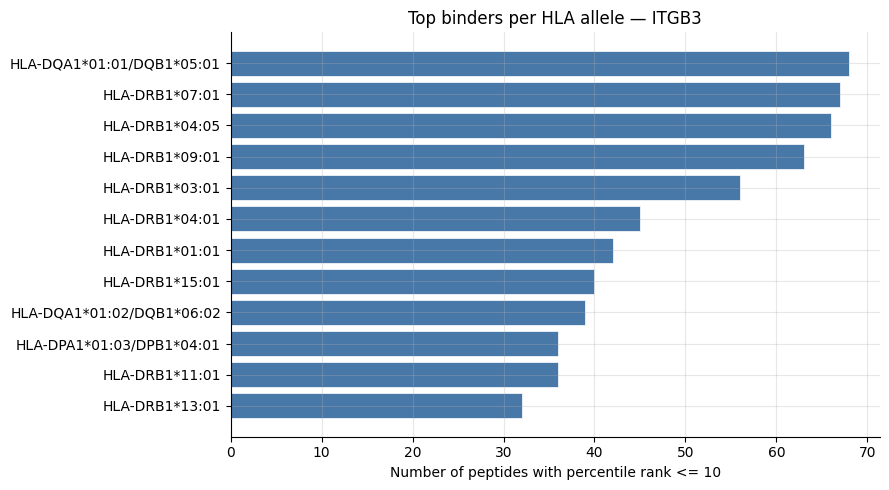


Alleles with any binders: 12 / 12


In [6]:
# Binders per allele
allele_counts = binders["allele"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(allele_counts.index, allele_counts.values, color="#4878A8",
        edgecolor="white", linewidth=0.5)
ax.set_xlabel("Number of peptides with percentile rank <= 10")
ax.set_title("Top binders per HLA allele — ITGB3")
plt.tight_layout()
plt.show()

print(f"\nAlleles with any binders: {len(allele_counts)} / {len(HLA_PANEL)}")

In [7]:
# Save top binders for downstream use
out_path = Path("data/processed/itgb3_top_binders.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
binders.to_csv(out_path, index=False)
print(f"Saved {len(binders)} binder rows to {out_path}")

Saved 590 binder rows to data/processed/itgb3_top_binders.csv


---
## Section 5 — Benchmark Recovery

The critical validation question: **do top-ranked predictions recover
known ITP epitopes at a rate above chance?**

We rank all 774 peptides by their best (lowest) percentile rank across
all alleles, then measure what fraction of the 86 known ITP epitopes
from IEDB appear in the top N% of that ranking.

The **random baseline** is the recovery you'd expect if predictions had
no signal — approximately `top_n_percent / 100`. If recovery is
substantially above this line, the prediction engine is working.

In [8]:
# Rank peptides by their best percentile rank across all alleles
best_per_peptide = (
    full_results
    .groupby("peptide")["percentile_rank"]
    .min()
    .sort_values()
)
ranked_peptides = best_per_peptide.index.tolist()

print(f"Ranked peptides: {len(ranked_peptides)}")
print(f"Known epitopes:  {len(known_epitopes)}")
print()

# Key thresholds
for pct in [5, 10, 20, 50]:
    result = benchmark_recovery(ranked_peptides, known_epitopes, top_n_percent=pct)
    print(
        f"  Top {pct:>2}%: "
        f"{result['recovered']:>2}/{result['total_known']} recovered "
        f"({result['recovery_rate']:.1%}) "
        f"— random baseline {pct/100:.1%} "
        f"— using top {result['top_n_count']} peptides"
    )

Ranked peptides: 774
Known epitopes:  86

  Top  5%:  5/86 recovered (5.8%) — random baseline 5.0% — using top 38 peptides
  Top 10%: 11/86 recovered (12.8%) — random baseline 10.0% — using top 77 peptides
  Top 20%: 19/86 recovered (22.1%) — random baseline 20.0% — using top 154 peptides
  Top 50%: 44/86 recovered (51.2%) — random baseline 50.0% — using top 387 peptides


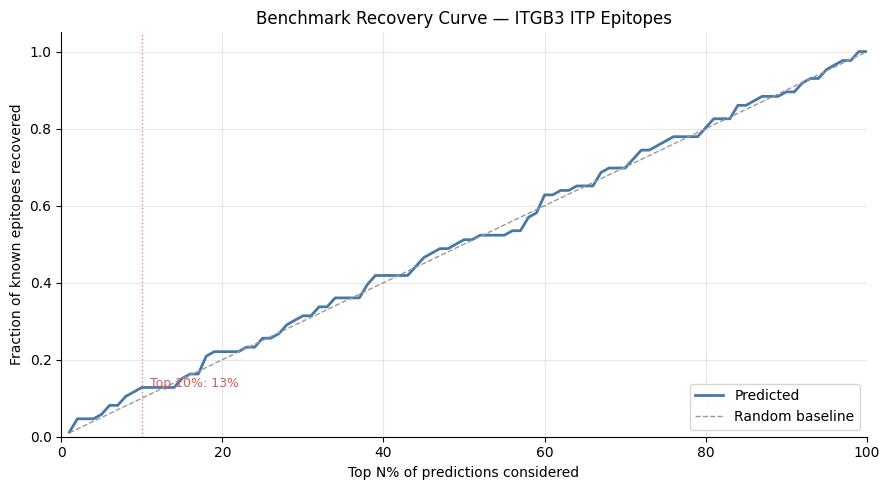

In [9]:
# Recovery curve: sweep top_n_percent from 1 to 100
sweep = list(range(1, 101))
recovery_rates = []

for pct in sweep:
    r = benchmark_recovery(ranked_peptides, known_epitopes, top_n_percent=pct)
    recovery_rates.append(r["recovery_rate"])

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(sweep, recovery_rates, color="#4878A8", linewidth=2, label="Predicted")
ax.plot(sweep, [p / 100 for p in sweep], color="#999999", linewidth=1,
        linestyle="--", label="Random baseline")

ax.set_xlabel("Top N% of predictions considered")
ax.set_ylabel("Fraction of known epitopes recovered")
ax.set_title("Benchmark Recovery Curve — ITGB3 ITP Epitopes")
ax.set_xlim(0, 100)
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")

# Highlight the 10% threshold
r10 = benchmark_recovery(ranked_peptides, known_epitopes, top_n_percent=10)
ax.axvline(10, color="#D45B5B", linestyle=":", linewidth=1, alpha=0.7)
ax.annotate(
    f"  Top 10%: {r10['recovery_rate']:.0%}",
    xy=(10, r10["recovery_rate"]),
    fontsize=9, color="#D45B5B",
)

plt.tight_layout()
plt.show()

---
## Section 6 — Conclusions

**How to read the recovery curve:**

If the blue line (predicted) sits well above the grey dashed line (random
baseline), the prediction engine is enriching for real epitopes — MHC-II
binding prediction has genuine signal for this antigen.

Key observations:

- **At top 10%**: this is the standard evaluation threshold. If recovery
  is 2–5x the random baseline (i.e. 20–50% vs the expected 10%), the
  predictions are working well. If recovery is close to or below the
  baseline, the prediction method may not be capturing ITP-relevant
  epitopes, and we should investigate why (wrong allele panel, wrong
  prediction method, or genuine biological complexity).

- **Steep early rise**: a curve that climbs steeply in the first 5–10%
  then flattens means the top-ranked peptides are genuinely enriched.
  This is the ideal shape.

- **Linear (tracking the baseline)**: means predictions are no better
  than random for this benchmark set. This could indicate that the known
  ITP epitopes in IEDB were identified through assays that don't
  correlate well with MHC-II binding affinity (e.g. T-cell proliferation
  assays with unresolved MHC restriction).

**Caveats on this benchmark:**

- The 86 known epitopes are predominantly from a few publications and
  may not represent the full ITP epitope landscape.
- Most IEDB records for ITGB3 have unresolved MHC restriction (annotated
  as `human` rather than a specific HLA allele), so we cannot confirm
  that our allele panel is the right one for these specific patients.
- The substring-based recovery metric is intentionally generous — see
  `benchmark_recovery` source for the documented assumption.

Regardless of the exact numbers, this notebook establishes the benchmark
methodology. As we refine the tolerogenic scoring in Phase 3, we will
re-run this curve to measure whether scoring improves epitope selection
beyond raw MHC-II binding alone.